In [45]:
import os
import datetime

import colorcet as cc
import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
import pandas as pd
from bokeh.plotting import figure, output_notebook, show
from bokeh.models import HoverTool, Title
from pathlib import Path
import folium
import rioxarray
import netCDF4

from shapely.geometry import box

from blackmarble.extract import bm_extract
from blackmarble.raster import bm_raster

import xarray as xr
import numpy as np

#Local Functions
import sys
sys.path.append('../src')
from ntl_functions import plot_NASA_NTL, filter_dataset_by_bounding_box

#Settings
%load_ext autoreload
%autoreload 2

plt.rcParams["figure.figsize"] = (18, 10)
pd.set_option('display.max_rows', 50)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#Somalia Shape File Downlaoded from. 
#https://gadm.org/download_country.html
gdf = gpd.read_file(
    "../data/Combined_Datasets/gadm41_SOM_1.json.zip"
)
#Somaliland SHP File
somaliland_shp = gdf[gdf["HASC_1"].isin(["SO.AW", "SO.WO", "SO.TO", "SO.SA", "SO.SO"])]

In [10]:
somaliland_shp = gpd.read_file(
    "../data/Combined_Datasets/Somaliland_with_berbera/somaliland_with_berbera.shp"
)

In [11]:
SL_Berbera_VNP46A4_EY_2012_24 = xr.open_dataset("../data/NTL_Data_A4/SL_Berbera_VNP46A4_EY_2012_24.nc")
SL_Berbera_VNP46A4_EY_2012_24 = SL_Berbera_VNP46A4_EY_2012_24.where(SL_Berbera_VNP46A4_EY_2012_24 != 6553.5, 0)

logged_NTL = xr.where(
    SL_Berbera_VNP46A4_EY_2012_24 > 0, 
    np.log(SL_Berbera_VNP46A4_EY_2012_24), 
    0  # Assign 0 for non-positive values
)

C:\Users\samsa\anaconda3\Lib\site-packages\xarray\core\computation.py:761: RuntimeWarning: divide by zero encountered in log
  result_data = func(*input_data)


In [12]:
#Cities
HGA = gpd.read_file("../data/Combined_Datasets/Hargeisa_shp/HGA.shp")
Berbera = gpd.read_file("../data/Combined_Datasets/Berbera_shp/Berbera.shp")
Burao = gpd.read_file("../data/Combined_Datasets/Burao_shp/Burao.shp")
Boroma = gpd.read_file("../data/Combined_Datasets/Boroma_shp/Boroma.shp")
Erigavo = gpd.read_file("../data/Combined_Datasets/Erigavo_shp/Erigavo.shp")
Las_Anod = gpd.read_file("../data/Combined_Datasets/Las_Anod_shp/Las_Anod.shp")



# Data Processing

In [13]:
# For graphing
HGA_NTL = filter_dataset_by_bounding_box(SL_Berbera_VNP46A4_EY_2012_24, HGA)
Berbera_NTL = filter_dataset_by_bounding_box(SL_Berbera_VNP46A4_EY_2012_24, Berbera)
Burao_NTL = filter_dataset_by_bounding_box(SL_Berbera_VNP46A4_EY_2012_24, Burao)
Boroma_NTL = filter_dataset_by_bounding_box(SL_Berbera_VNP46A4_EY_2012_24, Boroma)
Erigavo_NTL = filter_dataset_by_bounding_box(SL_Berbera_VNP46A4_EY_2012_24, Erigavo)
Las_Anod_NTL = filter_dataset_by_bounding_box(SL_Berbera_VNP46A4_EY_2012_24, Las_Anod)


In [14]:
# For graphing
log_HGA_NTL = filter_dataset_by_bounding_box(logged_NTL, HGA)
log_Berbera_NTL = filter_dataset_by_bounding_box(logged_NTL, Berbera)
log_Burao_NTL = filter_dataset_by_bounding_box(logged_NTL, Burao)
log_Boroma_NTL = filter_dataset_by_bounding_box(logged_NTL, Boroma)
log_Erigavo_NTL = filter_dataset_by_bounding_box(logged_NTL, Erigavo)
log_Las_Anod_NTL = filter_dataset_by_bounding_box(logged_NTL, Las_Anod)


<Axes: >

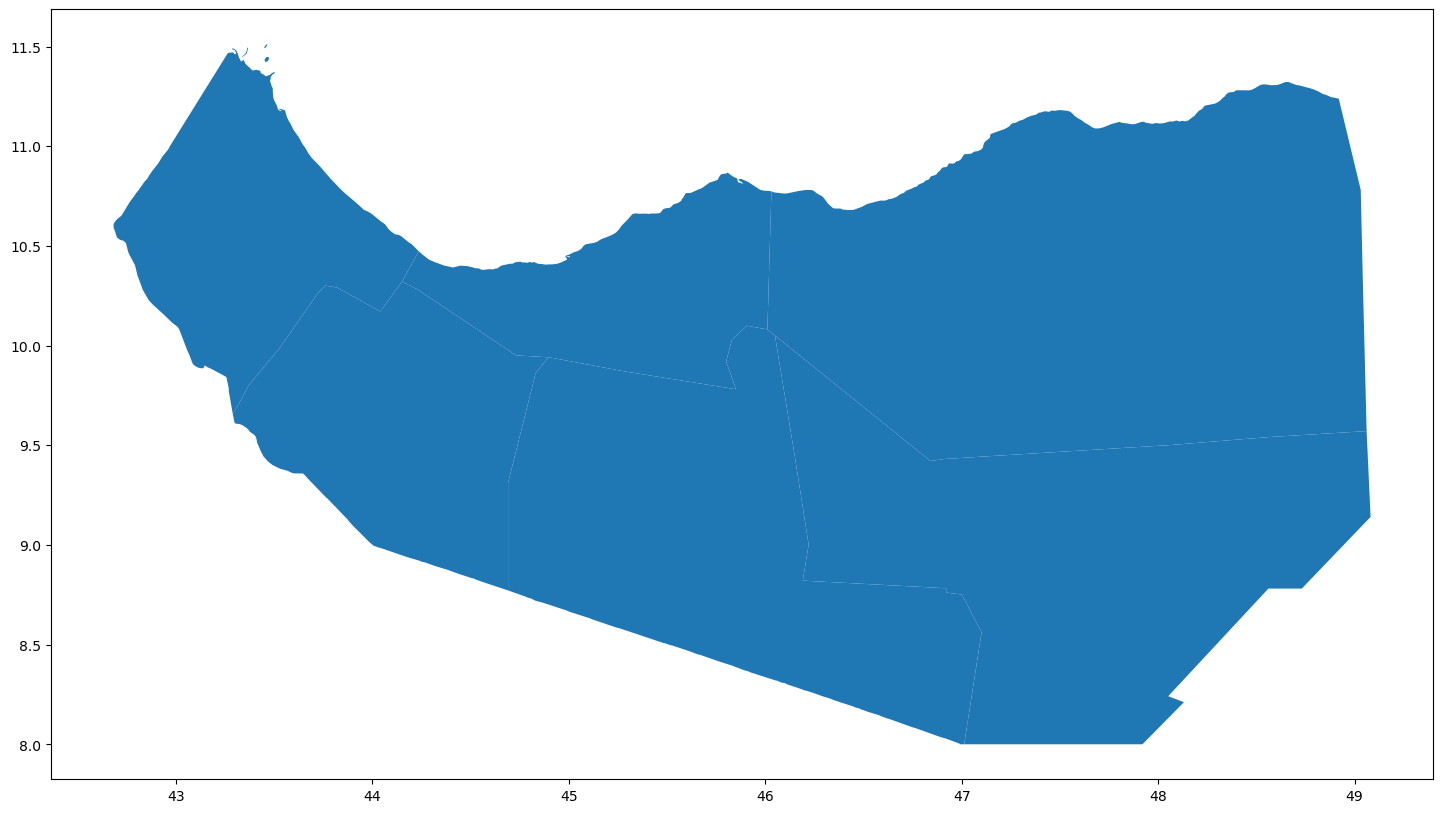

In [15]:
somaliland_shp.plot()

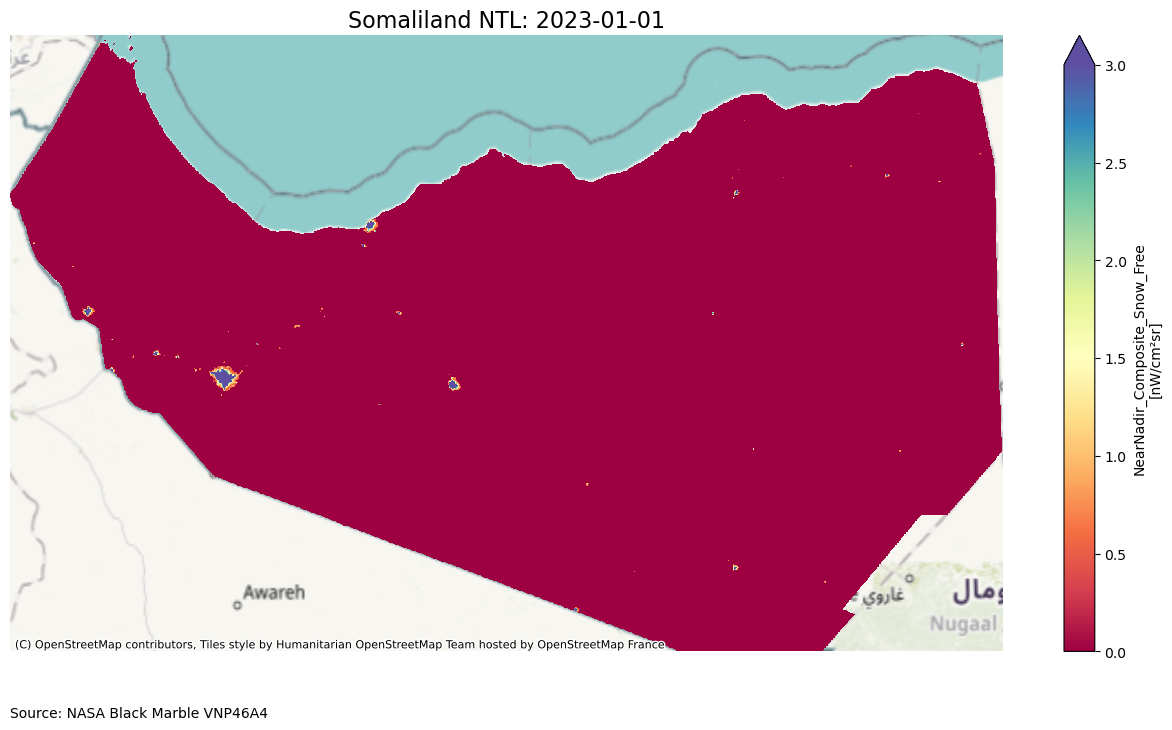

In [19]:
plot_NASA_NTL(SL_Berbera_VNP46A4_EY_2012_24, somaliland_shp, date = "2023-01-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Somaliland NTL",
              robust = False, vmin=0, vmax=3)
plt.savefig(f'../output/Graphics/SL_2023.png', dpi=300, bbox_inches='tight')  

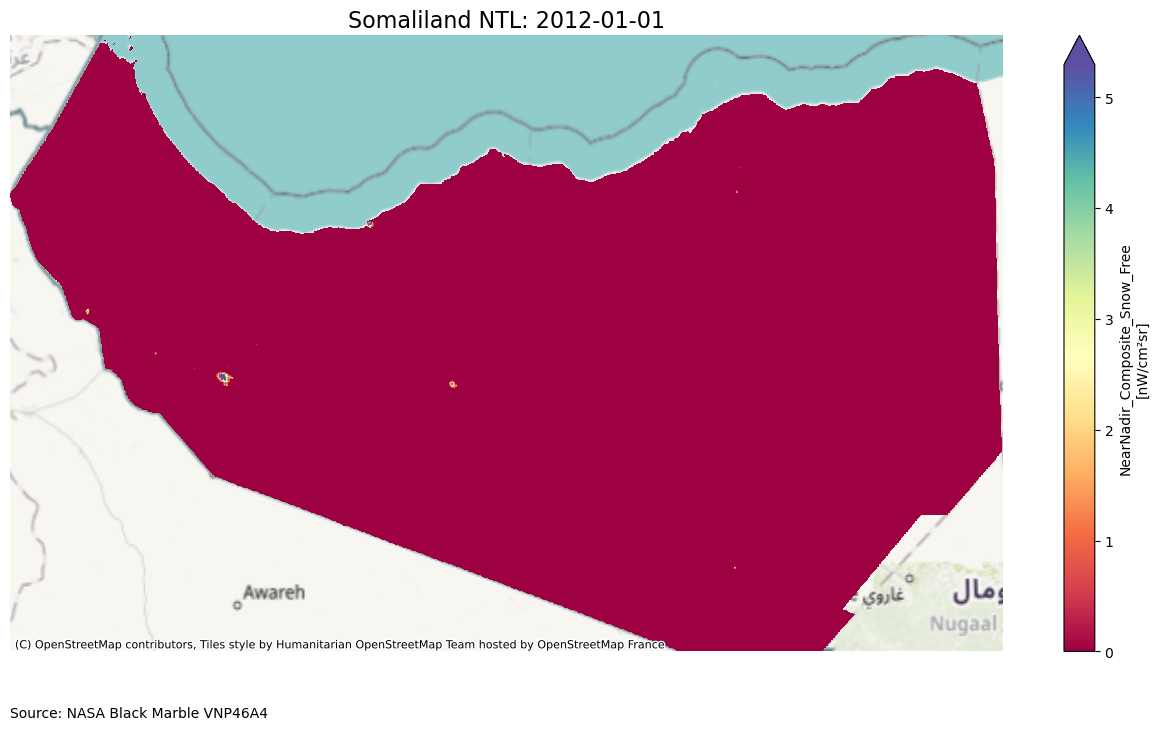

In [18]:
plot_NASA_NTL(SL_Berbera_VNP46A4_EY_2012_24, somaliland_shp, date = "2012-01-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Somaliland NTL",
              robust = False, vmin=0, vmax = logged_NTL["NearNadir_Composite_Snow_Free"].max())
plt.savefig(f'../output/Graphics/SL_2012.png', dpi=300, bbox_inches='tight')  

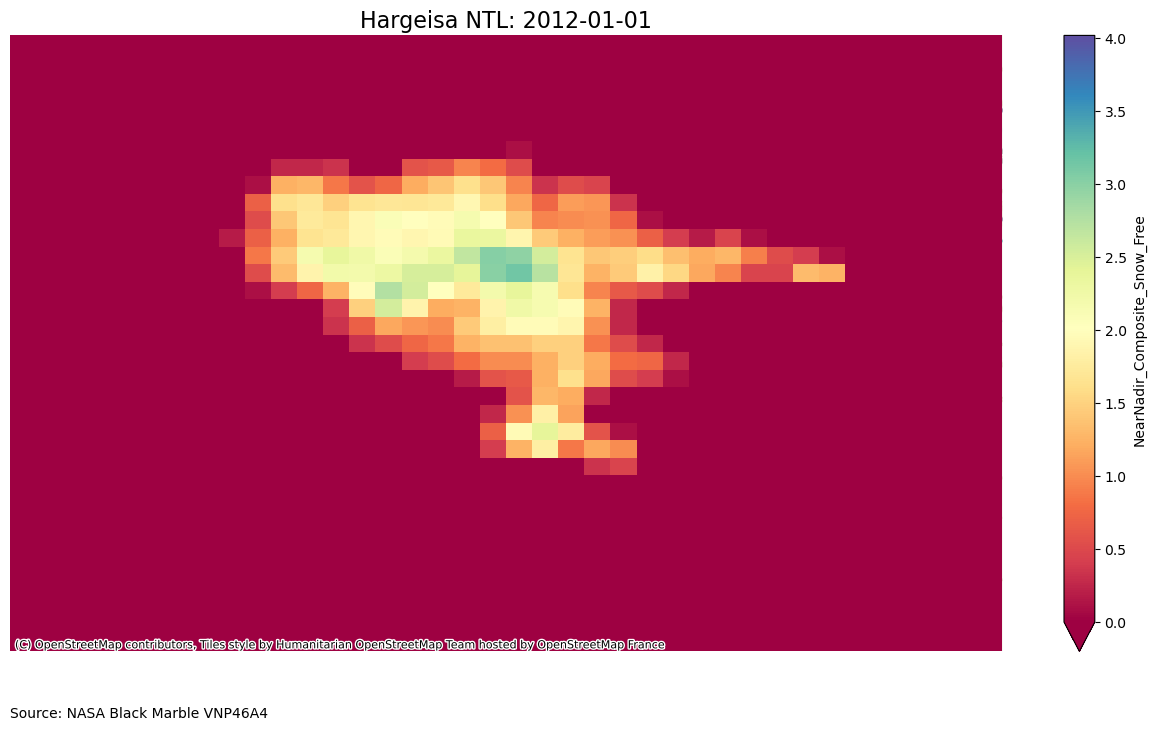

In [20]:
plot_NASA_NTL(log_HGA_NTL, HGA, date = "2012-01-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Hargeisa NTL",
              robust = False, vmin=0, vmax = log_HGA_NTL["NearNadir_Composite_Snow_Free"].max())
plt.savefig(f'../output/Graphics/HGA_2012.png', dpi=300, bbox_inches='tight')  

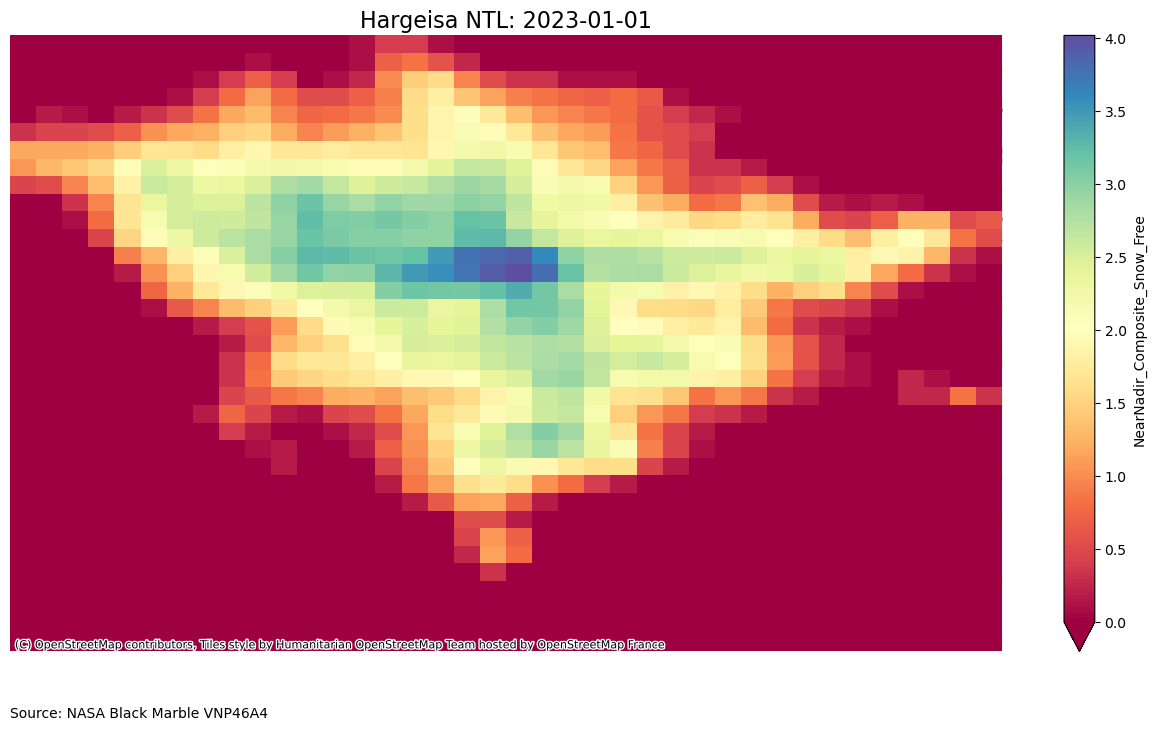

In [21]:
plot_NASA_NTL(log_HGA_NTL, HGA, date = "2023-01-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Hargeisa NTL",
              robust = False, vmin=0, vmax = log_HGA_NTL["NearNadir_Composite_Snow_Free"].max())
plt.savefig(f'../output/Graphics/HGA_2023.png', dpi=300, bbox_inches='tight')  

In [22]:
HGA_yearly_sums = []
for year in range(2012, 2024):
    # Select data for the year and sum all values
    yearly_sum = HGA_NTL["NearNadir_Composite_Snow_Free"].sel(time=f"{year}-01-01").sum().item()
    HGA_yearly_sums.append(yearly_sum)

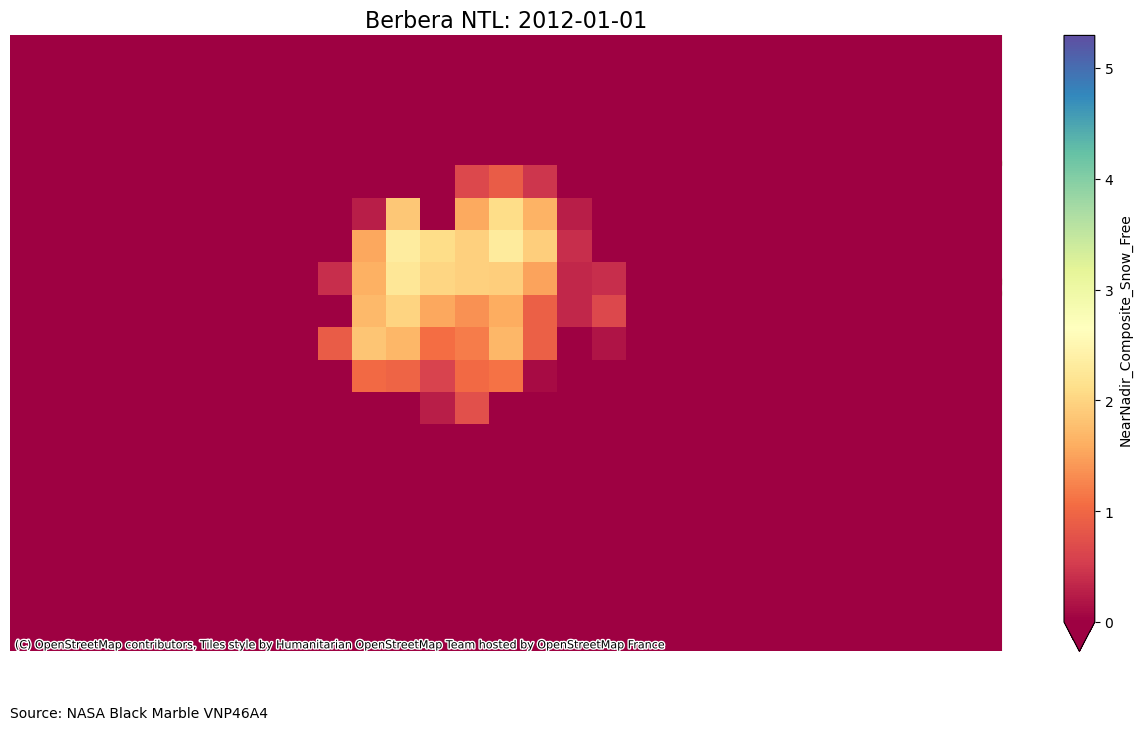

In [23]:
plot_NASA_NTL(log_Berbera_NTL, Berbera, date = "2012-01-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Berbera NTL",
              robust = False, vmin=0, vmax = log_Berbera_NTL["NearNadir_Composite_Snow_Free"].max())
plt.savefig(f'../output/Graphics/Berbera_2012.png', dpi=300, bbox_inches='tight')  

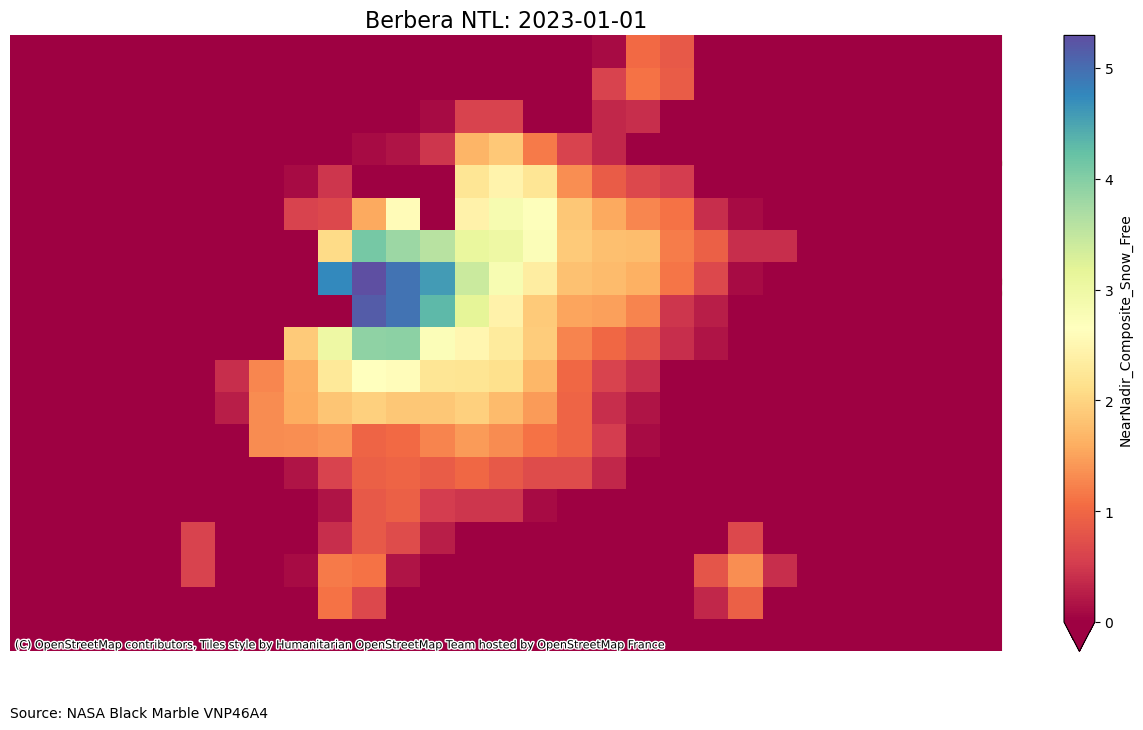

In [24]:
plot_NASA_NTL(log_Berbera_NTL, Berbera, date = "2023-01-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Berbera NTL",
              robust = False, vmin=0, vmax = log_Berbera_NTL["NearNadir_Composite_Snow_Free"].max())
plt.savefig(f'../output/Graphics/Berbera_2023.png', dpi=300, bbox_inches='tight')  

In [25]:
Berbera_yearly_sums = []
for year in range(2012, 2024):
    # Select data for the year and sum all values
    yearly_sum = Berbera_NTL["NearNadir_Composite_Snow_Free"].sel(time=f"{year}-01-01").sum().item()
    Berbera_yearly_sums.append(yearly_sum)

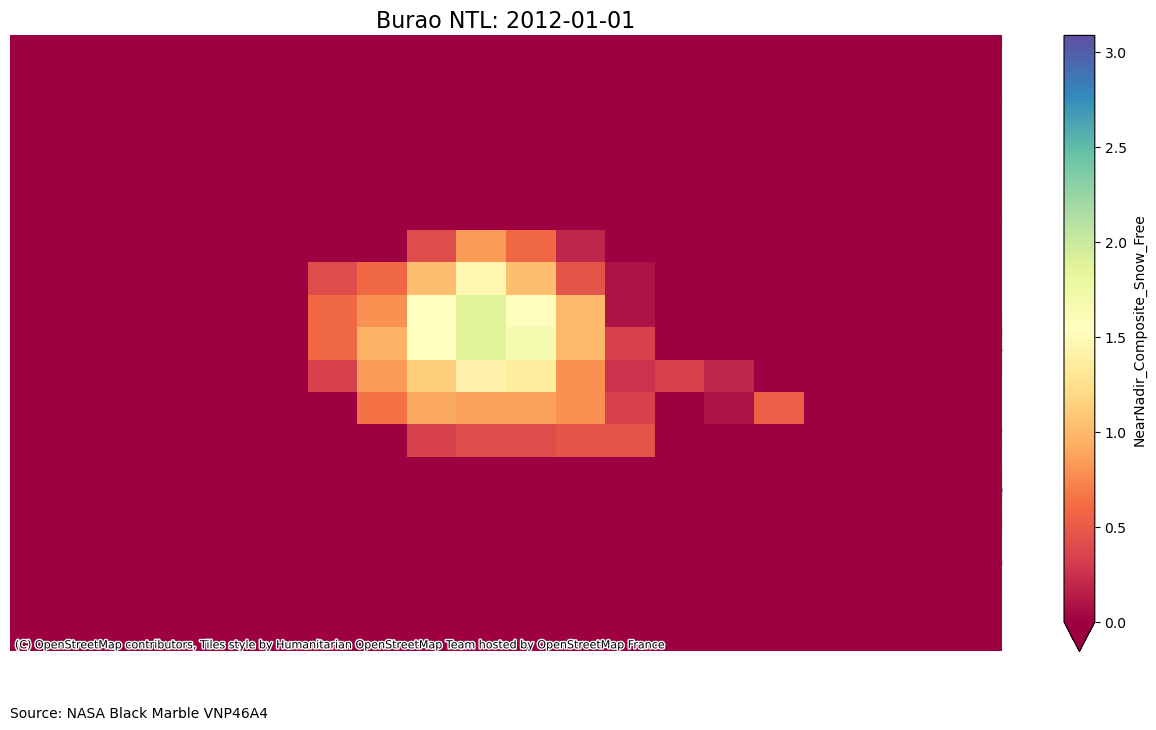

In [26]:
plot_NASA_NTL(log_Burao_NTL, Burao, date = "2012-01-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Burao NTL",
              robust = False, vmin=0, vmax = log_Burao_NTL["NearNadir_Composite_Snow_Free"].max())
plt.savefig(f'../output/Graphics/Burao_2012.png', dpi=300, bbox_inches='tight')  

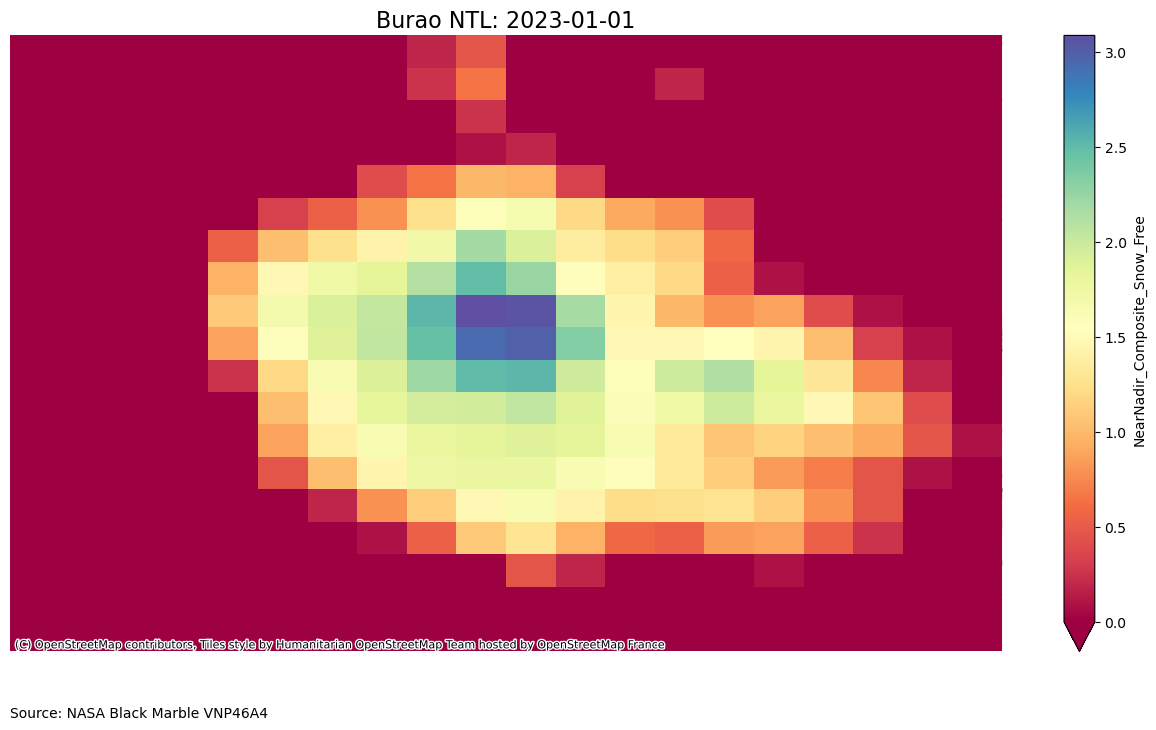

In [27]:
plot_NASA_NTL(log_Burao_NTL, Burao, date = "2023-01-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Burao NTL",
              robust = False, vmin=0, vmax = log_Burao_NTL["NearNadir_Composite_Snow_Free"].max())
plt.savefig(f'../output/Graphics/Burao_2023.png', dpi=300, bbox_inches='tight')  

In [28]:
Burao_yearly_sums = []
for year in range(2012, 2024):
    # Select data for the year and sum all values
    yearly_sum = Burao_NTL["NearNadir_Composite_Snow_Free"].sel(time=f"{year}-01-01").sum().item()
    Burao_yearly_sums.append(yearly_sum)

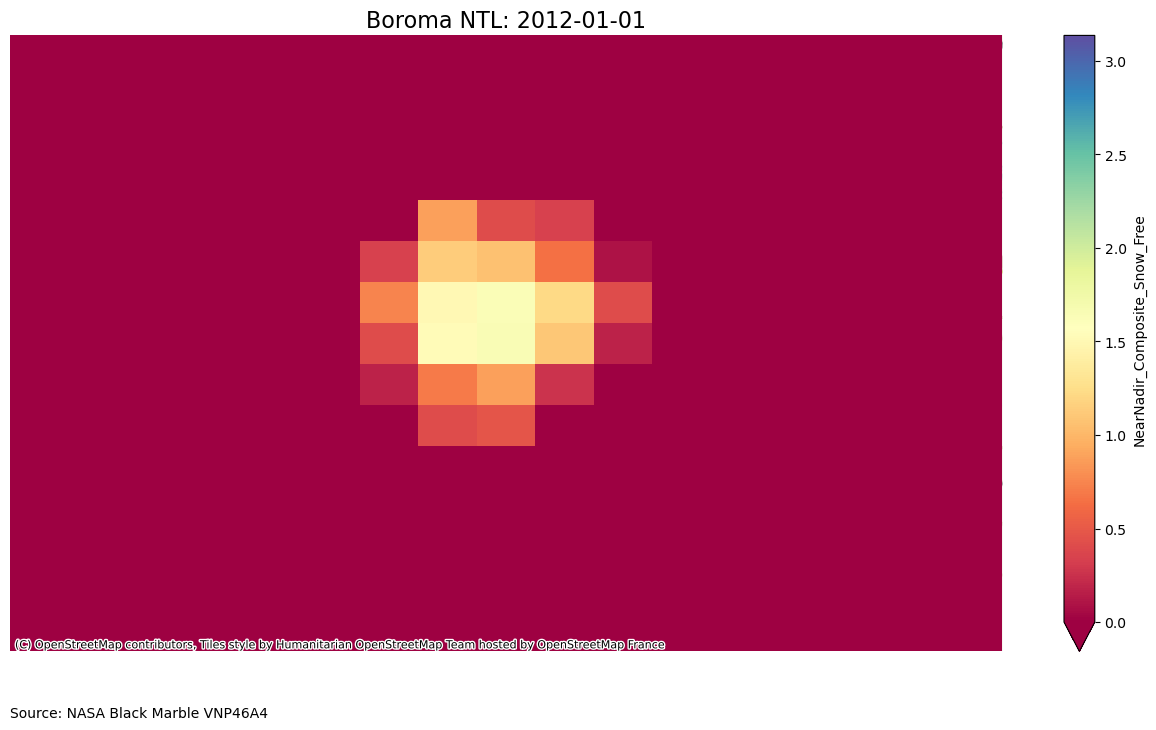

In [29]:
plot_NASA_NTL(log_Boroma_NTL, Boroma, date = "2012-01-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Boroma NTL",
              robust = False, vmin=0, vmax = log_Boroma_NTL["NearNadir_Composite_Snow_Free"].max())
plt.savefig(f'../output/Graphics/Boroma_2012.png', dpi=300, bbox_inches='tight')  

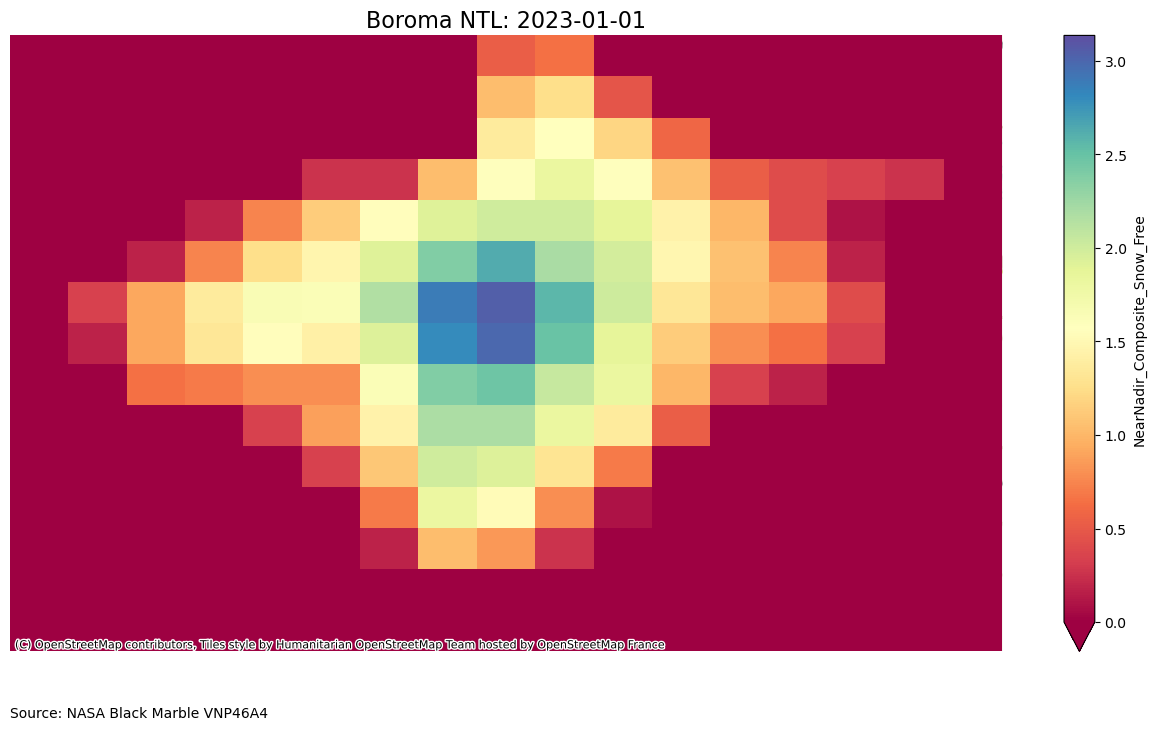

In [30]:
plot_NASA_NTL(log_Boroma_NTL, Boroma, date = "2023-01-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Boroma NTL",
              robust = False, vmin=0, vmax = log_Boroma_NTL["NearNadir_Composite_Snow_Free"].max())
plt.savefig(f'../output/Graphics/Boroma_2023.png', dpi=300, bbox_inches='tight')  

In [31]:
Boroma_yearly_sums = []
for year in range(2012, 2024):
    # Select data for the year and sum all values
    yearly_sum = Boroma_NTL["NearNadir_Composite_Snow_Free"].sel(time=f"{year}-01-01").sum().item()
    Boroma_yearly_sums.append(yearly_sum)

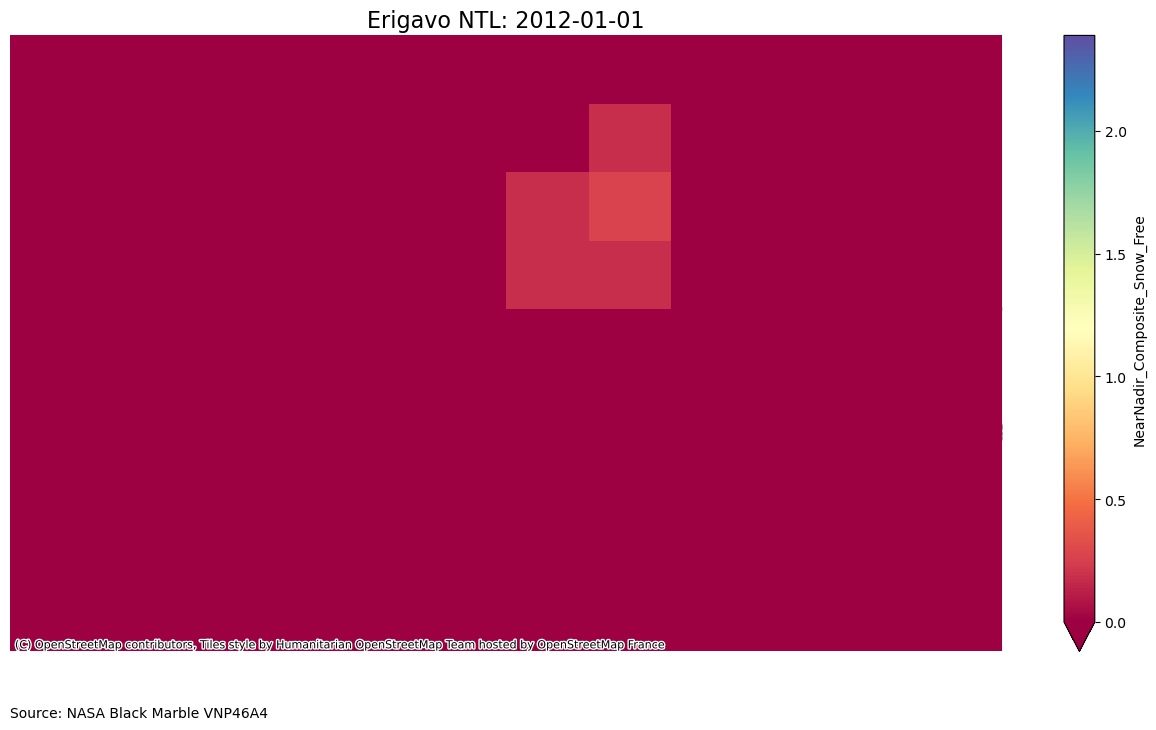

In [32]:
plot_NASA_NTL(log_Erigavo_NTL, Erigavo, date = "2012-01-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Erigavo NTL",
              robust = False, vmin=0, vmax = log_Erigavo_NTL["NearNadir_Composite_Snow_Free"].max())
plt.savefig(f'../output/Graphics/Erigavo_2012.png', dpi=300, bbox_inches='tight')  

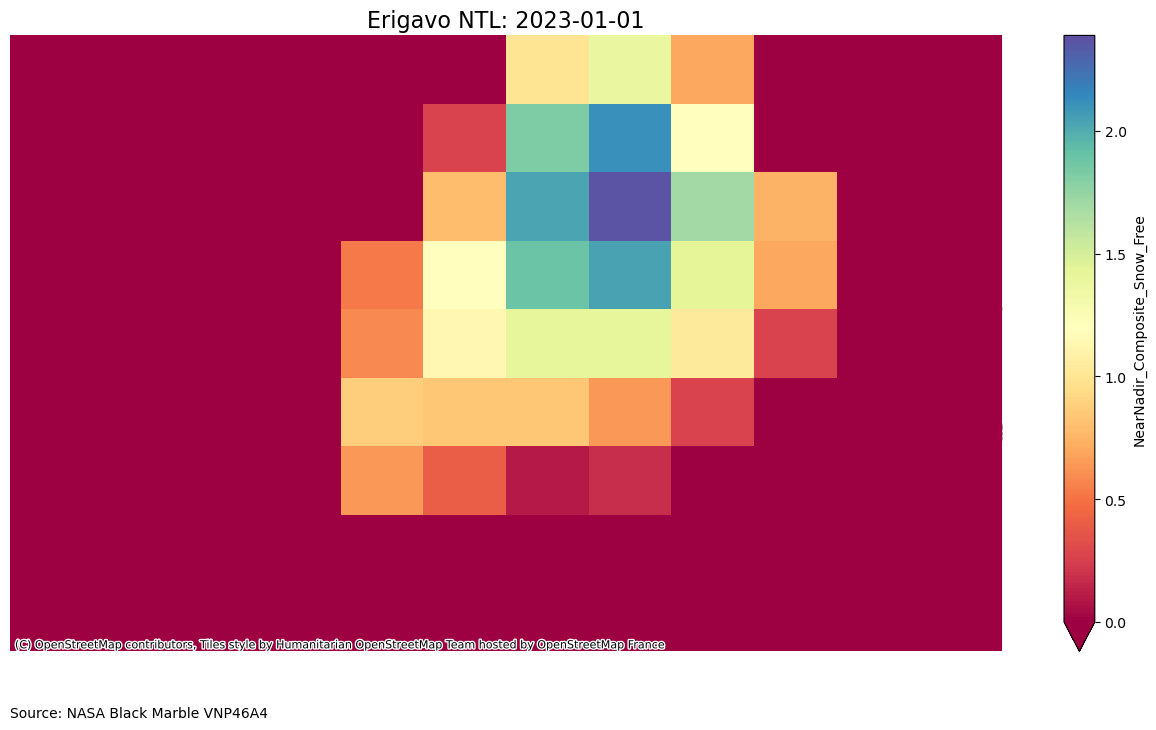

In [33]:
plot_NASA_NTL(log_Erigavo_NTL, Erigavo, date = "2023-01-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Erigavo NTL",
              robust = False, vmin=0, vmax = log_Erigavo_NTL["NearNadir_Composite_Snow_Free"].max())
plt.savefig(f'../output/Graphics/Erigavo_2023.png', dpi=300, bbox_inches='tight')  

In [34]:
Erigavo_yearly_sums = []
for year in range(2012, 2024):
    # Select data for the year and sum all values
    yearly_sum = Erigavo_NTL["NearNadir_Composite_Snow_Free"].sel(time=f"{year}-01-01").sum().item()
    Erigavo_yearly_sums.append(yearly_sum)

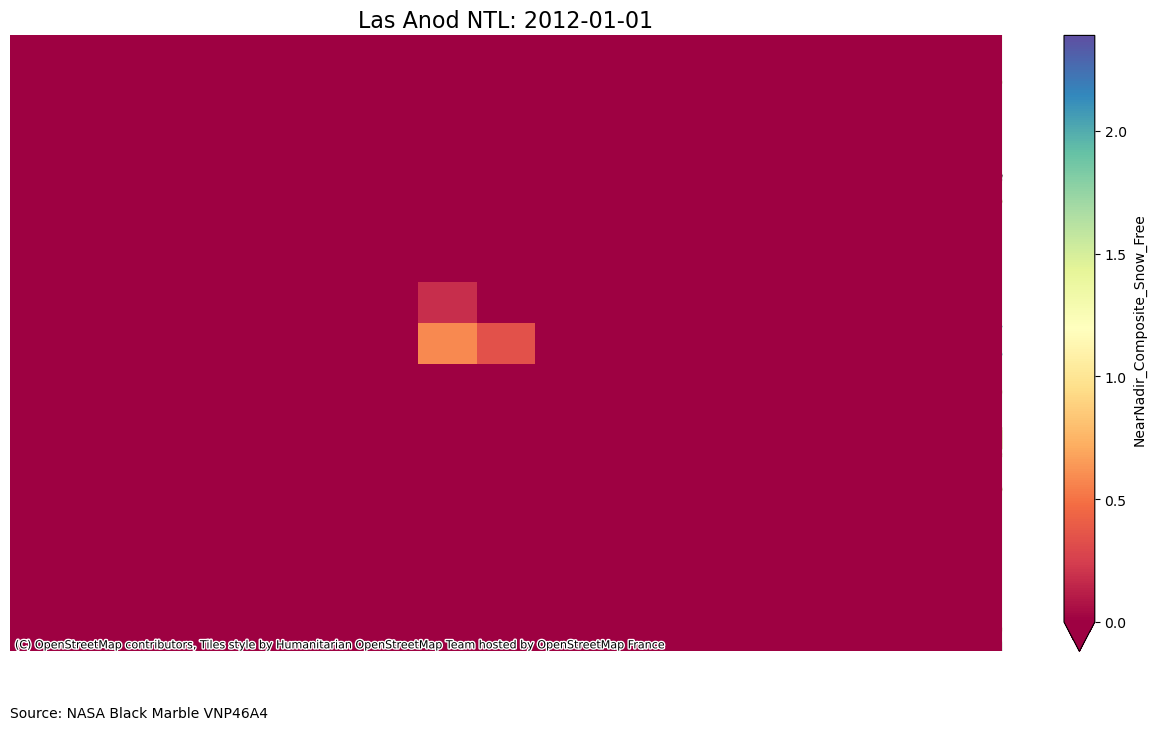

In [35]:
plot_NASA_NTL(log_Las_Anod_NTL, Las_Anod, date = "2012-01-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Las Anod NTL",
              robust = False, vmin=0, vmax = log_Las_Anod_NTL["NearNadir_Composite_Snow_Free"].max())
plt.savefig(f'../output/Graphics/Las_Anod_2012.png', dpi=300, bbox_inches='tight')  

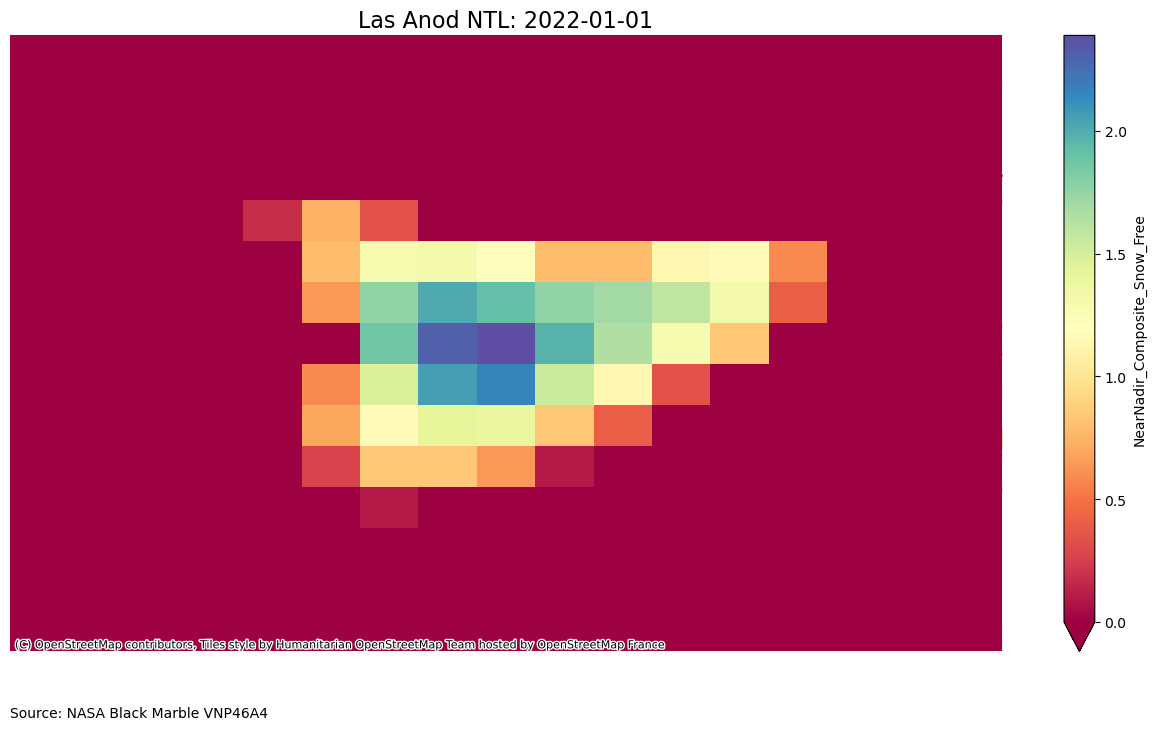

In [36]:
plot_NASA_NTL(log_Las_Anod_NTL, Las_Anod, date = "2022-01-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Las Anod NTL",
              robust = False, vmin=0, vmax = log_Las_Anod_NTL["NearNadir_Composite_Snow_Free"].max())
plt.savefig(f'../output/Graphics/Las_Anod_2022.png', dpi=300, bbox_inches='tight')  

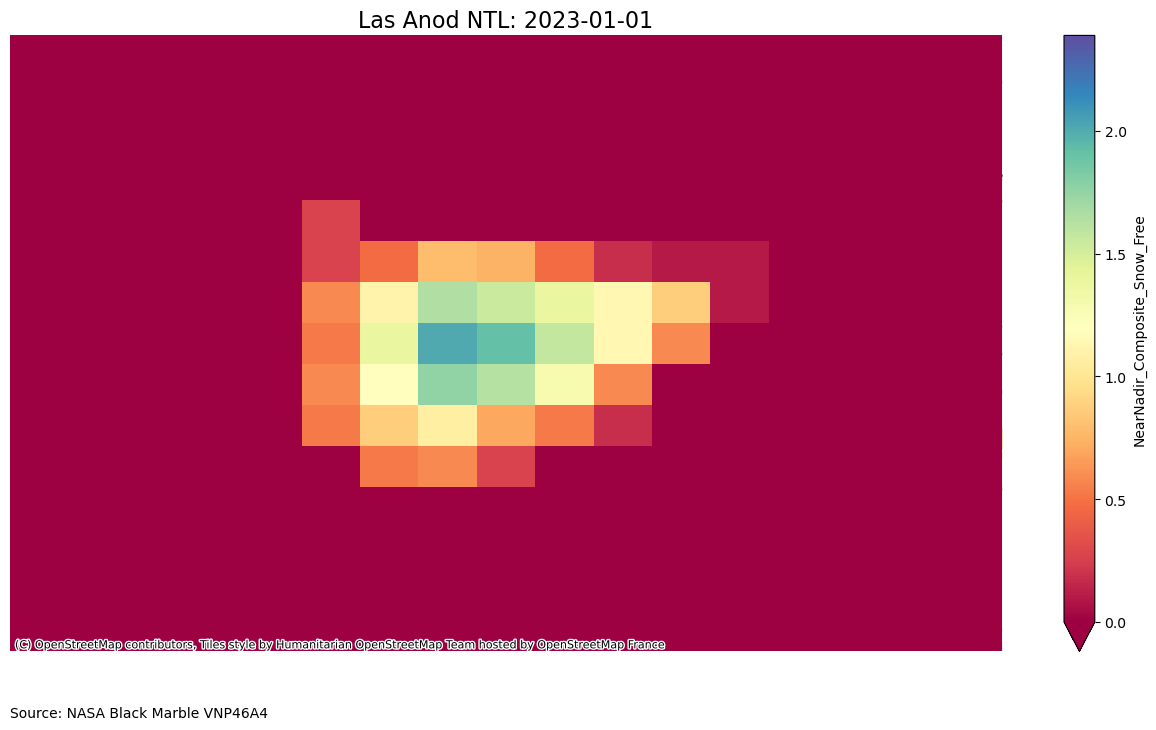

In [37]:
plot_NASA_NTL(log_Las_Anod_NTL, Las_Anod, date = "2023-01-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Las Anod NTL",
              robust = False, vmin=0, vmax = log_Las_Anod_NTL["NearNadir_Composite_Snow_Free"].max())
plt.savefig(f'../output/Graphics/Las_Anod_2023.png', dpi=300, bbox_inches='tight')  

In [38]:
Las_Anod_yearly_sums = []
for year in range(2012, 2024):
    # Select data for the year and sum all values
    yearly_sum = Las_Anod_NTL["NearNadir_Composite_Snow_Free"].sel(time=f"{year}-01-01").sum().item()
    Las_Anod_yearly_sums.append(yearly_sum)

In [39]:
city_sum = []
for i in range(0,12):
    summed = HGA_yearly_sums[i]+Berbera_yearly_sums[i] +\
    Boroma_yearly_sums[i]+ Burao_yearly_sums[i] + Erigavo_yearly_sums[i] +\
    Las_Anod_yearly_sums[i]
    city_sum.append(summed)

In [40]:
total_yearly_sums = []
for year in range(2012, 2024):
    # Select data for the year and sum all values
    yearly_sum = SL_Berbera_VNP46A4_EY_2012_24["NearNadir_Composite_Snow_Free"].sel(time=f"{year}-01-01").sum().item()
    total_yearly_sums.append(yearly_sum)

In [41]:
#All cities
#Hargeisa, Berbera, Boroma, Burco, Eerigavo, Las Anood
#Total

In [42]:
df = pd.DataFrame({
    "Year": list(range(2012, 2024)),
    "SL Total":total_yearly_sums, 
    "All Cities": city_sum,
    "Hargeisa" : HGA_yearly_sums,
    "Berbera" : Berbera_yearly_sums,
    "Boroma" : Boroma_yearly_sums,
    "Burco": Burao_yearly_sums, 
    "Erigavo" : Erigavo_yearly_sums, 
    "Las Anod" : Las_Anod_yearly_sums, 
    })

df = df.round(1)

In [43]:
df

,Year,SL Total,All Cities,Hargeisa,Berbera,Boroma,Burco,Erigavo,Las Anod
0,2012,1546.4,1524.4,1066.2,220.1,70.0,146.6,10.2,11.3
1,2013,1713.4,1685.1,1103.3,267.9,102.6,154.6,8.4,48.3
2,2014,1870.7,1821.8,1235.4,242.9,92.6,168.3,13.8,68.8
3,2015,2039.3,1983.0,1375.2,261.6,94.1,170.8,14.3,67.0
4,2016,2212.0,2130.3,1474.8,283.0,88.3,187.6,15.3,81.3
5,2017,2603.4,2478.3,1721.3,305.3,116.8,233.9,16.1,84.9
6,2018,3354.8,3172.0,2112.7,498.6,158.1,294.4,23.8,84.4
7,2019,4107.6,3811.0,2498.6,570.8,199.4,407.7,36.2,98.3
8,2020,5216.7,4829.6,3119.3,746.2,288.8,491.5,55.3,128.5
9,2021,7172.7,6512.5,3935.2,1282.4,428.1,617.1,90.0,159.7
